# Davis: NumPy Polynomial Fit

Fit fuel use against speed for **vehicle 119, trip 985** using NumPy ordinary least squares. The quadratic model is

$$\text{fuel\_use} = w_2\,\text{speed}^2 + w_1\,\text{speed} + b.$$

It is polynomial in speed but linear in the unknown weights. The design matrix columns are `[speed², speed, 1]`, so `np.linalg.lstsq` returns `[w₂, w₁, b]` in that order.

## Data and cleaning rule

The input is `data/ved_vehicle119_trip985.csv`, the team’s VED extract. The response is the existing `fuel_use_L_per_100km` column. Fuel use is calculated by dividing fuel rate by speed, so low-speed observations can produce unusually large values. Following the team’s selected cleaning rule, this fit **excludes rows below 10 km/h**. The next cell reports how many rows are retained.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_FILE = "ved_vehicle119_trip985.csv"
MIN_SPEED_KMH = 10
required_columns = {
    "VehId",
    "Trip",
    "Vehicle Speed[km/h]",
    "fuel_use_L_per_100km",
}

project_root = Path.cwd().resolve()
while not (project_root / "data" / DATA_FILE).is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError(
            f"Could not find data/{DATA_FILE} from the notebook's working directory."
        )
    project_root = project_root.parent

data_path = project_root / "data" / DATA_FILE
raw = pd.read_csv(data_path)
missing_columns = required_columns.difference(raw.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

trip_df = raw.loc[(raw["VehId"] == 119) & (raw["Trip"] == 985)].copy()
if trip_df.empty:
    raise ValueError("No rows found for vehicle 119, trip 985.")

speed_column = "Vehicle Speed[km/h]"
fuel_use_column = "fuel_use_L_per_100km"
if trip_df[[speed_column, fuel_use_column]].isna().any().any():
    raise ValueError("Speed or fuel-use values are missing in the selected trip.")

rows_before_filter = len(trip_df)
df = trip_df.loc[trip_df[speed_column] >= MIN_SPEED_KMH].copy()
if len(df) < 3:
    raise ValueError("At least three observations are needed for a quadratic fit.")

print(f"Data: {data_path}")
print("Vehicle 119, trip 985")
print(f"Rows before speed filter: {rows_before_filter}")
print(f"Rows retained (speed >= {MIN_SPEED_KMH} km/h): {len(df)}")
print(f"Rows excluded: {rows_before_filter - len(df)}")

Data: C:\Users\Davisen\Documents\GitHub\ved-fuel-speed-linearization\data\ved_vehicle119_trip985.csv
Vehicle 119, trip 985
Rows before speed filter: 496
Rows retained (speed >= 10 km/h): 426
Rows excluded: 70


## Build the design matrix and fit

For each observation, one design-matrix row is `[speed², speed, 1]`. Least squares chooses weights that minimize the sum of squared differences between observed and predicted fuel use.

In [2]:
speed = df[speed_column].to_numpy(dtype=float)
speed_sq = speed**2
fuel_use = df[fuel_use_column].to_numpy(dtype=float)

design_matrix = np.column_stack((speed_sq, speed, np.ones_like(speed)))
weights, residual_sum_squares, rank, singular_values = np.linalg.lstsq(
    design_matrix, fuel_use, rcond=None
)
w2, w1, b = weights
fuel_use_pred = design_matrix @ weights

print("Design matrix columns: [speed², speed, 1]")
print(f"Design matrix shape: {design_matrix.shape}")
print(f"Rank: {rank}")
print(f"w₂ = {w2:.8f} L/100km per (km/h)²")
print(f"w₁ = {w1:.8f} L/100km per (km/h)")
print(f"b  = {b:.8f} L/100km")
print(f"Least-squares residual sum of squares: {residual_sum_squares[0]:.8f}")

Design matrix columns: [speed², speed, 1]
Design matrix shape: (426, 3)
Rank: 3
w₂ = 0.01014007 L/100km per (km/h)²
w₁ = -1.11868780 L/100km per (km/h)
b  = 44.39952151 L/100km
Least-squares residual sum of squares: 246294.62312001


## Predictions and interpretation

The fitted weights describe the curvature (`w₂`), the linear contribution (`w₁`), and the intercept (`b`). They are coefficients of the whole fitted curve, so interpret them together rather than as separate causal effects. The plot overlays the NumPy predictions on the observations used for fitting.

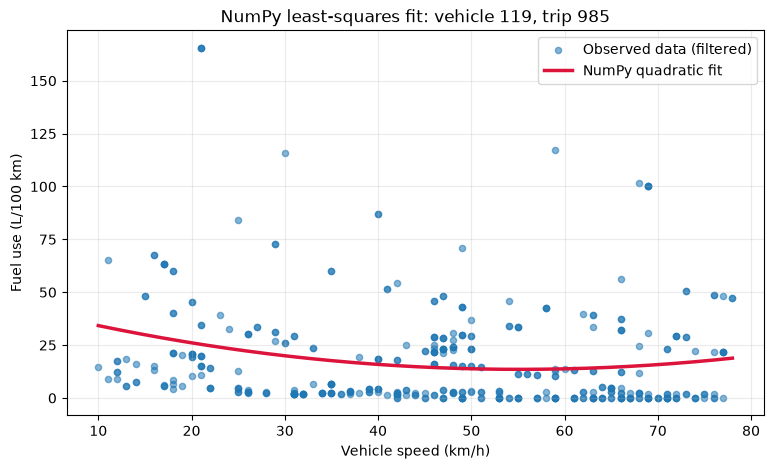

In [3]:
speed_line = np.linspace(speed.min(), speed.max(), 300)
design_line = np.column_stack((speed_line**2, speed_line, np.ones_like(speed_line)))
fuel_use_line = design_line @ weights

plt.figure(figsize=(9, 5))
plt.scatter(speed, fuel_use, s=20, alpha=0.55, label="Observed data (filtered)")
plt.plot(speed_line, fuel_use_line, color="crimson", linewidth=2.5, label="NumPy quadratic fit")
plt.xlabel("Vehicle speed (km/h)")
plt.ylabel("Fuel use (L/100 km)")
plt.title("NumPy least-squares fit: vehicle 119, trip 985")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Handoff to the model-checking section

The fitted coefficients are available as `w2`, `w1`, and `b`; predictions on the filtered observations are in `fuel_use_pred`. The NumPy design-matrix column order is `[speed², speed, 1]`. The model comparison, R²/RMSE metrics, and residual plots belong in the team’s model-checking section.